In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def log_likelihood(vr, mu, sig, e_vr=0):
    total_var = sig**2 + e_vr**2
    single_logp = -0.5 * (np.log(2 * np.pi * total_var) + (vr - mu) ** 2 / total_var)
    return np.sum(single_logp)

In [2]:
def draw(set,num=None,min_mu=-500,max_mu=-200,min_sig=0.1,max_sig=80,e_vr_on=False):
    df = pd.read_csv(set)
    if num is None:
        vr_data = df["vr"].values
        e_vr=df["e_vr"].values
    else:
        vr_data = df["vr"].values[:num]
        e_vr=df["e_vr"].values[:num]

    mu_grid = np.linspace(min_mu, max_mu, 100)
    sig_grid = np.linspace(min_sig, max_sig, 100)
    mu_2d, sig_2d = np.meshgrid(mu_grid, sig_grid)
    lnL_map = np.zeros_like(mu_2d)

    for i, sig in enumerate(sig_grid):
        for j, mu in enumerate(mu_grid):
            if e_vr_on:
                lnL_map[i, j] = log_likelihood(vr_data, mu, sig, e_vr)
            else:
                lnL_map[i, j] = log_likelihood(vr_data, mu, sig)

    max_idx = np.unravel_index(np.argmax(lnL_map), lnL_map.shape)
    best_mu = mu_grid[max_idx[1]]
    best_sig = sig_grid[max_idx[0]]
    print(f"Best mean vr = {best_mu:.2f} km/s, best sigma_vr = {best_sig:.2f} km/s")

    delta_lnL = lnL_map - np.max(lnL_map)
    delta_lnL_plot = np.clip(delta_lnL, -20, 0)

    plt.figure(figsize=(6, 3))
    heat = plt.contourf(
        mu_2d,
        sig_2d,
        delta_lnL_plot,
        levels=np.linspace(-20, 0, 41),
        cmap="viridis",
    )
    plt.scatter(best_mu, best_sig, c="red", edgecolors="black", s=60, zorder=10, label="Best Fit")
    plt.xlabel(r"$\bar{v}_r$ (km s$^{-1}$)")
    plt.ylabel(r"$\sigma_{vr}$ (km s$^{-1}$)")
    plt.title("Relative Log-Likelihood Contour Heatmap")
    plt.colorbar(heat, label=r"$\Delta\ln\mathcal{L}$")
    plt.legend()
    plt.tight_layout()
    plt.show()

Best mean vr = -372.73 km/s, best sigma_vr = 9.78 km/s


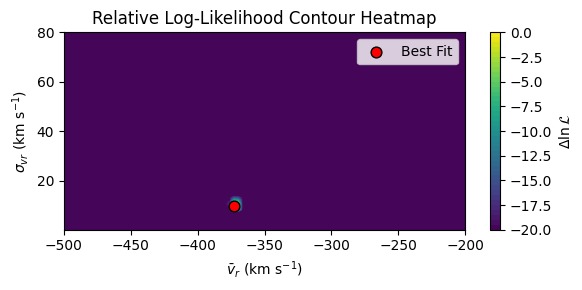

Best mean vr = -375.76 km/s, best sigma_vr = 6.56 km/s


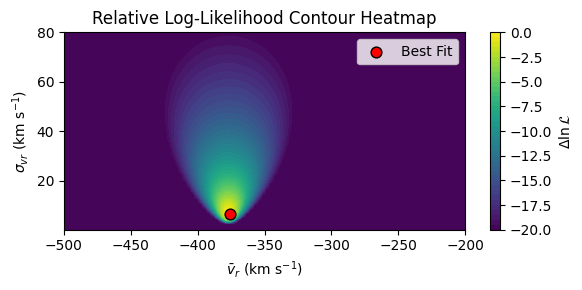

Best mean vr = -378.79 km/s, best sigma_vr = 4.14 km/s


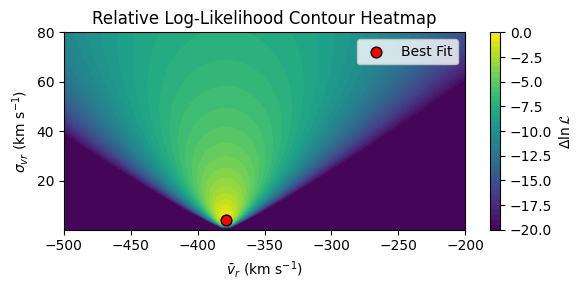

Best mean vr = -378.79 km/s, best sigma_vr = 0.91 km/s


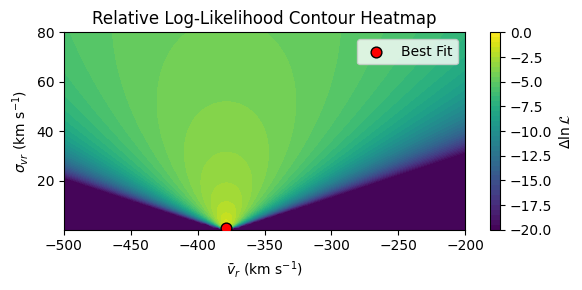

In [3]:
draw("data/cas3.csv", None)
draw("data/cas3.csv", 10)
draw("data/cas3.csv", 3)
draw("data/cas3.csv", 1)

Best mean vr = -196.97 km/s, best sigma_vr = 11.19 km/s


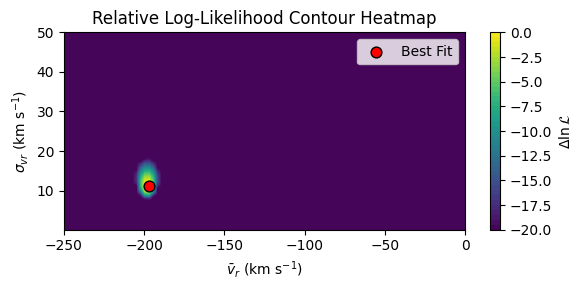

Best mean vr = -191.92 km/s, best sigma_vr = 8.67 km/s


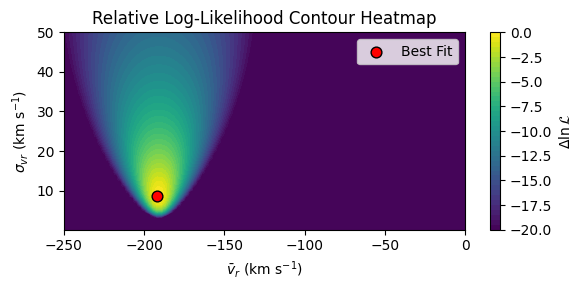

Best mean vr = -189.39 km/s, best sigma_vr = 4.64 km/s


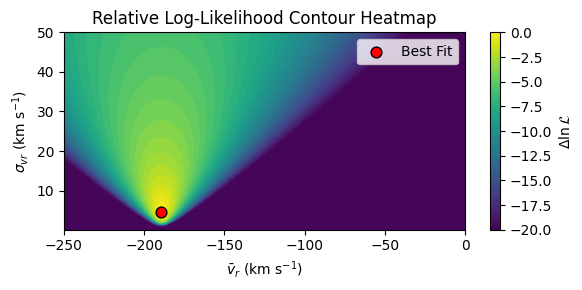

Best mean vr = -194.44 km/s, best sigma_vr = 1.11 km/s


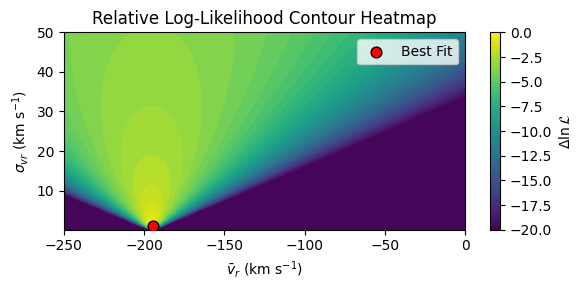

In [4]:
min_mu ,max_mu,min_sig,max_sig = -250,0,0.1,50
draw("data/lac1.csv", None,min_mu,max_mu,min_sig,max_sig)
draw("data/lac1.csv", 10,min_mu,max_mu,min_sig,max_sig)
draw("data/lac1.csv", 3,min_mu,max_mu,min_sig,max_sig)
draw("data/lac1.csv", 1,min_mu,max_mu,min_sig,max_sig)

Best mean vr = -327.27 km/s, best sigma_vr = 8.98 km/s


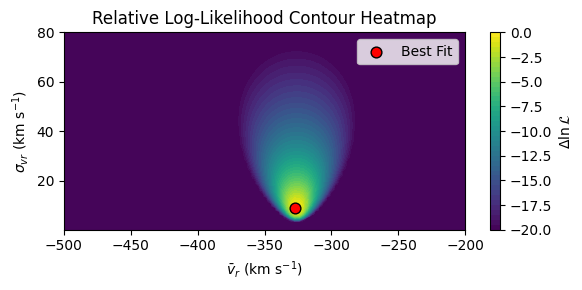

Best mean vr = -324.24 km/s, best sigma_vr = 8.98 km/s


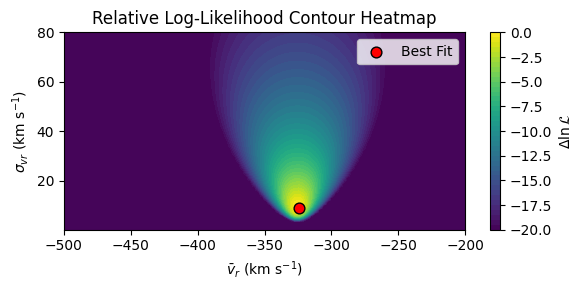

Best mean vr = -330.30 km/s, best sigma_vr = 11.40 km/s


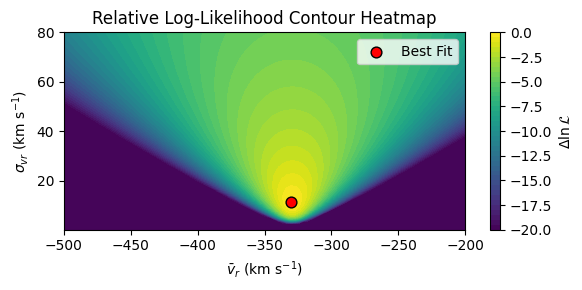

Best mean vr = -345.45 km/s, best sigma_vr = 0.91 km/s


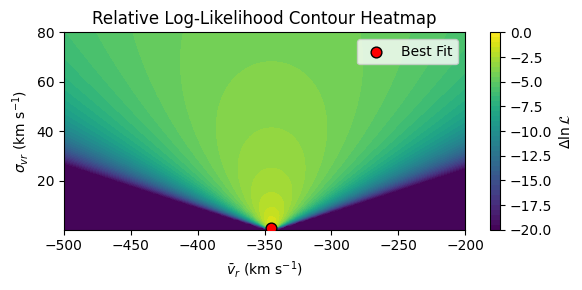

In [5]:
draw("data/per1.csv", None)
draw("data/per1.csv", 10)
draw("data/per1.csv", 3)
draw("data/per1.csv", 1)

In [6]:
def draw_multi_contour(set_path, num_list, min_mu=-500, max_mu=-200, min_sig=0.1, max_sig=80):
    df = pd.read_csv(set_path)
    color_pool = ["blue", "orange", "green", "red", "purple", "cyan"]
    mu_grid = np.linspace(min_mu, max_mu, 100)
    sig_grid = np.linspace(min_sig, max_sig, 100)
    mu_2d, sig_2d = np.meshgrid(mu_grid, sig_grid)

    plt.figure(figsize=(9, 5))
    for idx, num in enumerate(num_list):
        if num is None:
            vr_data = df["vr"].values
        else:
            vr_data = df["vr"].values[:num]
        lnL_map = np.zeros_like(mu_2d)
        for i, sig in enumerate(sig_grid):
            for j, mu in enumerate(mu_grid):
                lnL_map[i, j] = log_likelihood(vr_data, mu, sig)
        delta_lnL = lnL_map - np.max(lnL_map)
        max_idx = np.unravel_index(np.argmax(lnL_map), lnL_map.shape)
        best_mu = mu_grid[max_idx[1]]
        best_sig = sig_grid[max_idx[0]]
        print(f"样本数 {num}: Best mu={best_mu:.2f}, Best sig={best_sig:.2f}")

        c = color_pool[idx % len(color_pool)]
        cont = plt.contour(
            mu_2d, sig_2d, delta_lnL,
            levels=[-4.61, -2.3],  # 99.7%、95%置信线
            colors=c,
            linewidths=1.2,
            label=f"N={num}"
        )
        plt.clabel(cont, inline=True, fontsize=7)
        plt.scatter(best_mu, best_sig, color=c, s=50, zorder=10, label=f"N={num}")

    plt.xlabel(r"$\bar{v}_r$ (km s$^{-1}$)")
    plt.ylabel(r"$\sigma_{vr}$ (km s$^{-1}$)")
    plt.title("Contours for Different Star Numbers (Only Confidence Lines)")
    plt.legend()
    plt.tight_layout()
    plt.show()

样本数 None: Best mu=-372.73, Best sig=9.78
样本数 10: Best mu=-375.76, Best sig=6.56


C:\Users\32166\AppData\Local\Temp\ipykernel_29404\3581466753.py:25: UserWarning: The following kwargs were not used by contour: 'label'
  cont = plt.contour(


样本数 3: Best mu=-378.79, Best sig=4.14
样本数 1: Best mu=-378.79, Best sig=0.91


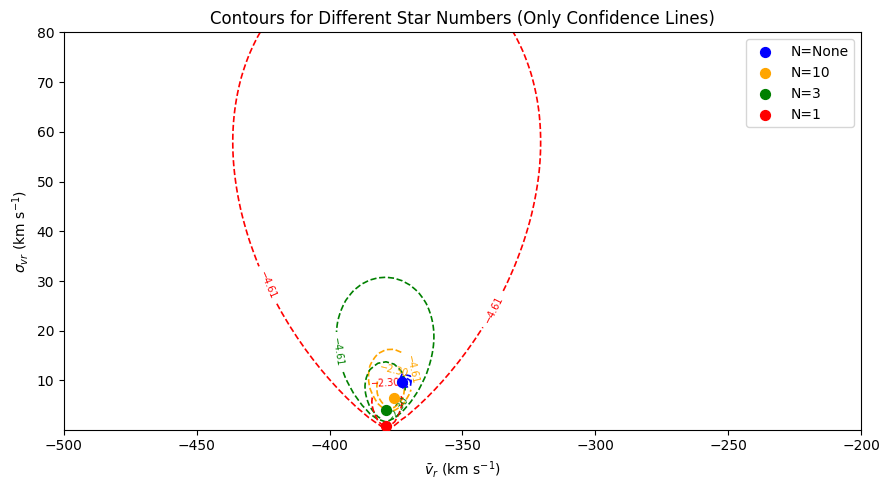

样本数 None: Best mu=-196.97, Best sig=11.19
样本数 10: Best mu=-191.92, Best sig=8.67


C:\Users\32166\AppData\Local\Temp\ipykernel_29404\3581466753.py:25: UserWarning: The following kwargs were not used by contour: 'label'
  cont = plt.contour(


样本数 3: Best mu=-189.39, Best sig=4.64
样本数 1: Best mu=-194.44, Best sig=1.11


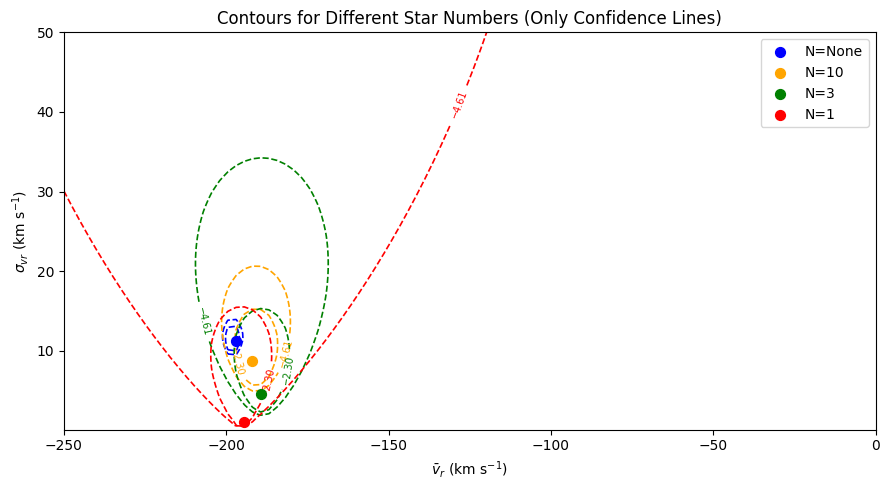

样本数 None: Best mu=-327.27, Best sig=8.98
样本数 10: Best mu=-324.24, Best sig=8.98


C:\Users\32166\AppData\Local\Temp\ipykernel_29404\3581466753.py:25: UserWarning: The following kwargs were not used by contour: 'label'
  cont = plt.contour(


样本数 3: Best mu=-330.30, Best sig=11.40
样本数 1: Best mu=-345.45, Best sig=0.91


In [7]:
draw_multi_contour("data/cas3.csv",[None,10,3,1])
draw_multi_contour("data/lac1.csv",[None,10,3,1],-250,0,0.1,50)
draw_multi_contour("data/per1.csv",[None,10,3,1])

Best mean vr = -371.52 km/s, best sigma_vr = 9.55 km/s


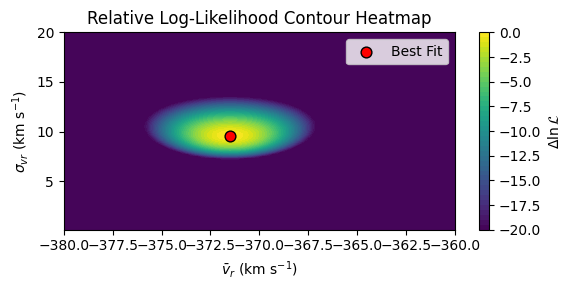

Best mean vr = -371.52 km/s, best sigma_vr = 8.34 km/s


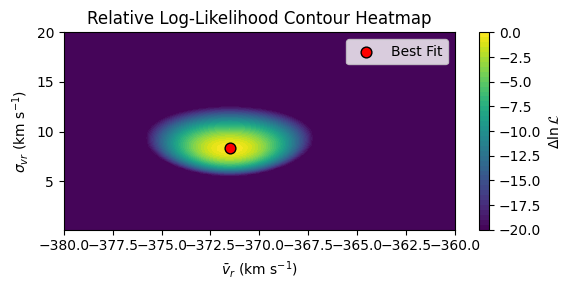

In [8]:
draw("data/cas3.csv",e_vr_on=False,min_mu=-380,max_mu=-360,min_sig=0.1,max_sig=20)
draw("data/cas3.csv",e_vr_on=True,min_mu=-380,max_mu=-360,min_sig=0.1,max_sig=20)